In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "Myeloid"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

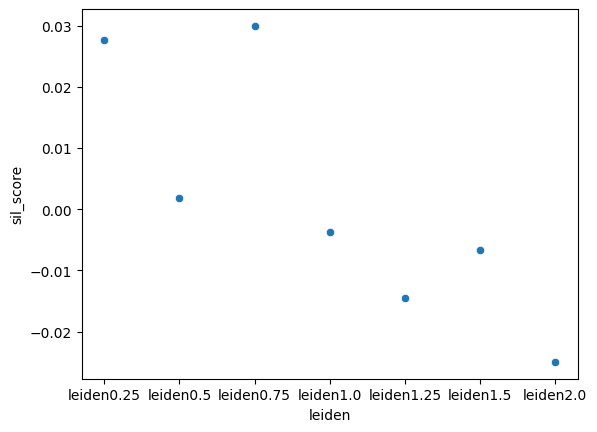

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Use Leiden 0.25

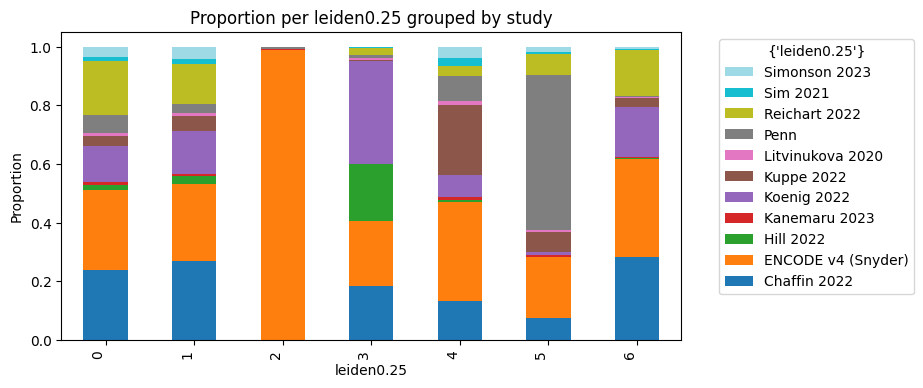

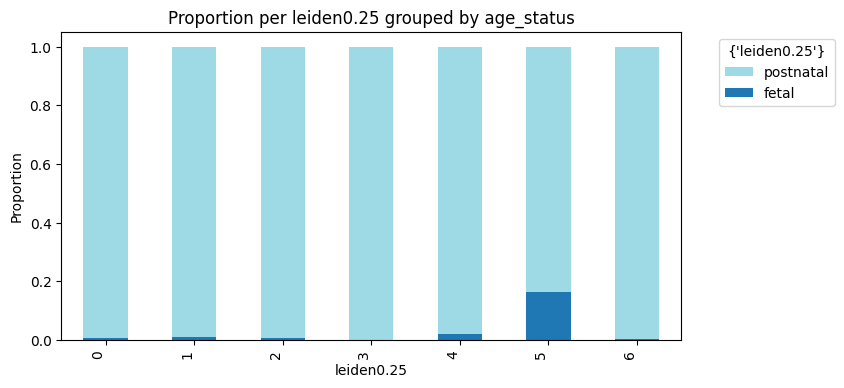

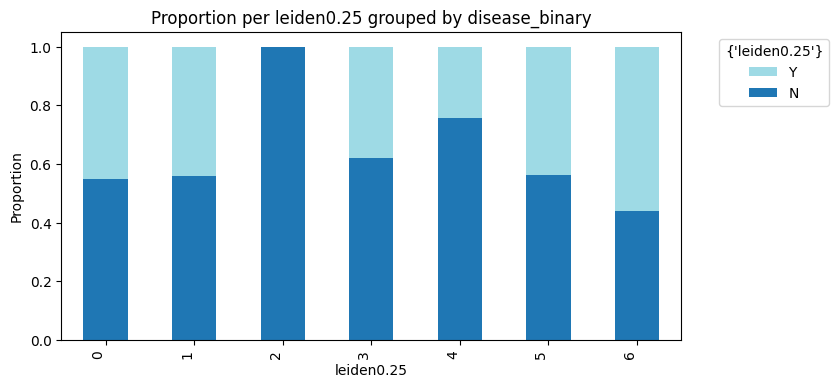

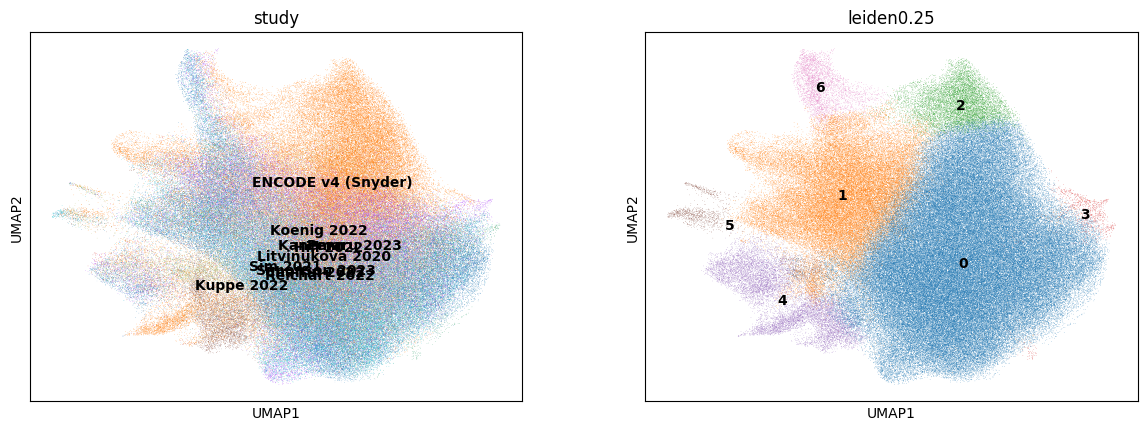

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (sel

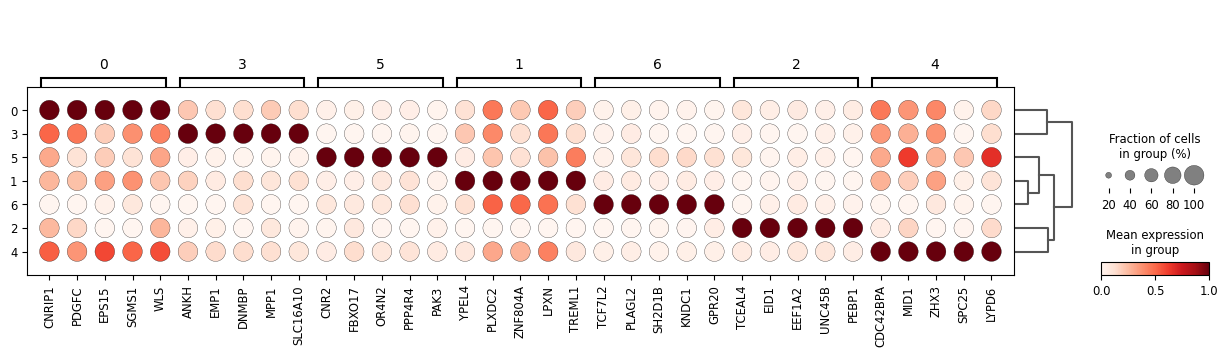

Counter({'0': 164461, '1': 49696, '4': 11244, '2': 9236, '6': 3529, '5': 2202, '3': 969})


['leiden0.25',
 AnnData object with n_obs × n_vars = 241337 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.1', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', 

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Cluster 0 is the main cluster of macrophages
- Cluster 1 is pro-inflammatory (IFNGR1/CLEC5A/CCR5/CCR2)
- Cluster 2 are primarily from one study
- Cluster 3 are anti-inflammatory (IL10/IL4R/HMOX1)
- Cluster 4 are cycling cells (MYBL2/CDC42BPA/ROCK2)
- Cluster 5 are conventional dendritic cells (CLEC4C/XCR1/BTLA)
- Cluster 6 are monocytes (CD16 aka FCGR3A and CD11a aka ITGAL)

In [7]:
sc.get.rank_genes_groups_df(adata, group="6").head(50)['names']

0       TCF7L2
1       PLAGL2
2       SH2D1B
3        KNDC1
4        GPR20
5         GCH1
6          LYN
7      PPP1R17
8      CYP4F22
9        P2RY2
10      SLC2A6
11        LYST
12     FAM110A
13       CASP5
14     TNFRSF8
15     CEACAM3
16       PLAC8
17      LILRB1
18      NEURL1
19        PAG1
20      UMODL1
21      PTP4A2
22       ZPLD1
23       RAB24
24       L1TD1
25    APOBEC3A
26    SERPINA1
27      LILRB2
28      CPPED1
29       ITGAL
30     SLC5A10
31        ABI3
32        CD48
33       CD101
34        UTRN
35       PRKCB
36        LST1
37     SLC44A2
38     L3MBTL3
39    RAP1GAP2
40      LILRA5
41       RAB37
42      FCGR3A
43        NAAA
44     TMEM63C
45      KIF21B
46       CHST2
47     CD300LF
48    C19orf38
49       AP2A1
Name: names, dtype: object

In [8]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {
        "0": "Macrophage_other",
        "1": "Macrophage_pro_I",
        "2": "Macrophage_other",
        "3": "Macrophage_anti_I",
        "4": "Macrophage_cycling",
        "5": "Dendritic",
        "6": "Monocyte",
    }
)

subcluster_order = [
    "Macrophage_other",
    "Macrophage_pro_I",
    "Macrophage_anti_I",
    "Macrophage_cycling",
    "Dendritic",
    "Monocyte"
]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

subcluster_colors = {
    "Macrophage_other": "#D3D3D3",       # light gray
    "Macrophage_pro_I": "red",           # pro-inflammatory
    "Macrophage_anti_I": "green",        # anti-inflammatory
    "Macrophage_cycling": "cyan",        # cycling
    "Dendritic": "orange",             # cDC1
    "Monocyte": "yellow",             # cDC2
}

In [9]:
Counter(adata.obs.subcluster)

Counter({'Macrophage_other': 173697,
         'Macrophage_pro_I': 49696,
         'Macrophage_cycling': 11244,
         'Monocyte': 3529,
         'Dendritic': 2202,
         'Macrophage_anti_I': 969})

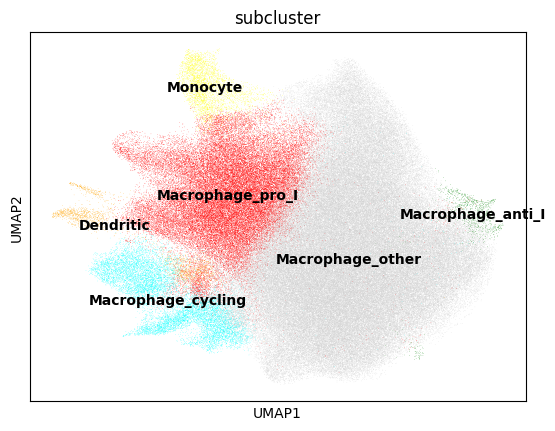

In [10]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig("Myeloid_subclustered.pdf", bbox_inches="tight")

- Cluster 0 is the main cluster of macrophages
- Cluster 1 is pro-inflammatory (IFNGR1/CLEC5A/CCR5/CCR2)
- Cluster 2 are primarily from one study
- Cluster 3 are anti-inflammatory (IL10/IL4R/HMOX1)
- Cluster 4 are cycling cells (MYBL2/CDC42BPA/ROCK2)
- Cluster 5 are conventional dendritic cells (CLEC4C/XCR1/BTLA)
- Cluster 6 are monocytes (CD16 aka FCGR3A and CD11a aka ITGAL)

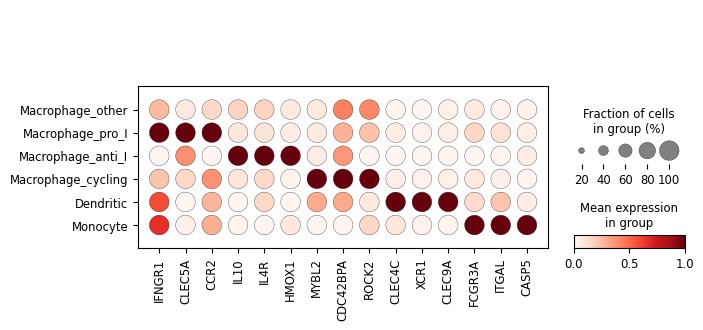

In [11]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["IFNGR1", "CLEC5A", "CCR2", 
                                      "IL10", "IL4R", "HMOX1", 
                                  "MYBL2", "CDC42BPA", "ROCK2",
                                     "CLEC4C", "XCR1", "CLEC9A",
                                     "FCGR3A", "ITGAL", "CASP5"], dot_max=1,
                  groupby = "subcluster", show=False, standard_scale='var')
    plt.savefig("Myeloid_subclustered_dotplot.pdf", bbox_inches="tight")

In [12]:
Counter(adata.obs.subcluster)

Counter({'Macrophage_other': 173697,
         'Macrophage_pro_I': 49696,
         'Macrophage_cycling': 11244,
         'Monocyte': 3529,
         'Dendritic': 2202,
         'Macrophage_anti_I': 969})

In [13]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

           subcluster   count  proportion
0    Macrophage_other  173697    0.719728
1    Macrophage_pro_I   49696    0.205920
2  Macrophage_cycling   11244    0.046590
3            Monocyte    3529    0.014623
4           Dendritic    2202    0.009124
5   Macrophage_anti_I     969    0.004015
